# <center>**Customer Transaction Prediction**</center>

**Member Name** :  **Chethan S (Individual)**  

**Project Deadline:**  : 15 days (5 April 2026 to 20  April 2026) 

**Team ID    :**   **PTID-CDS-MAR-26-4096**

**Project ID :**  **PRCP-1003-Customer Transaction Prediction**   

**Project submission date** :  **14 April 2026**

**Dataset used during Project   :** [CLick Here](https://d3ilbtxij3aepc.cloudfront.net/projects/CDS-Capstone-Projects/PRCP-1003-CustTransPred.zip)

---

## Dataset Column Reference

| Column Name | Description |
| --- | --- |
| **ID_code** | Unique identifier for each customer |
| **target** | Target variable: 1 = customer will make a transaction, 0 = will not |
| **var_0 … var_199** | 200 anonymized numeric features (real meaning is confidential) |

---

---
**This project works well with the following versions:**

---
* Python       :3.13.9
* NumPy        : 2.3.5
* Pandas       : 2.3.3
* Matplotlib   : 3.10.6
* Seaborn      : 0.13.2
* Scikit-learn : 1.7.2
* XGBoost      : 3.2.0

------

## Project structure

**Task 1:- Perform complete data analysis**

1. `import required libraries`
2. `load dataset`
3. `data inspection`
4. `data cleaning`
5. `class imbalance check`
6. `statistical summary`
7. `exploratory data analysis (eda)`

---

**Task 2:- Predict customer transaction**

8. `data preprocessing`
9. `feature scaling`
10. `train logistic regression (baseline)`
11. `train decision tree model`
12. `train random forest model`
13. `train xgboost model`
14. `model evaluation and comparison`
15. `random forest tuning`
16. `logistic regression tuning`
17. `select best model (xgboost)`
18. `final summary report`

---

**Task 3:- Challenges faced & business impact**

19. `feature importance analysis`
20. `challenges faced`
21. `business impact analysis`
22. `final recommendations`


## 1. Importing Required Libraries for Data Analysis & Machine Learning

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [71]:
data = pd.read_csv('/dataset/custpred.csv', sep=',')
df   = data.copy()

## 3. Data Inspection

In [72]:
df.head()

,ID_code,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,train_0,0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,train_1,0,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,train_2,0,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,train_3,0,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,train_4,0,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


In [73]:
df.shape

(200000, 202)

In [74]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Columns: 202 entries, ID_code to var_199
dtypes: float64(200), int64(1), object(1)
memory usage: 318.2 MB


In [75]:
df.describe()

,target,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.100490,10.679914,-1.627622,10.715192,6.796529,11.078333,-5.065317,5.408949,16.545850,0.284162,...,3.234440,7.438408,1.927839,3.331774,17.993784,-0.142088,2.303335,8.908158,15.870720,-3.326537
std,0.300653,3.040051,4.050044,2.640894,2.043319,1.623150,7.863267,0.866607,3.418076,3.332634,...,4.559922,3.023272,1.478423,3.992030,3.135162,1.429372,5.454369,0.921625,3.010945,10.438015
min,0.000000,0.408400,-15.043400,2.117100,-0.040200,5.074800,-32.562600,2.347300,5.349700,-10.505500,...,-14.093300,-2.691700,-3.814500,-11.783400,8.694400,-5.261000,-14.209600,5.960600,6.299300,-38.852800
25%,0.000000,8.453850,-4.740025,8.722475,5.254075,9.883175,-11.200350,4.767700,13.943800,-2.317800,...,-0.058825,5.157400,0.889775,0.584600,15.629800,-1.170700,-1.946925,8.252800,13.829700,-11.208475
50%,0.000000,10.524750,-1.608050,10.580000,6.825000,11.108250,-4.833150,5.385100,16.456800,0.393700,...,3.203600,7.347750,1.901300,3.396350,17.957950,-0.172700,2.408900,8.888200,15.934050,-2.819550
75%,0.000000,12.758200,1.358625,12.516700,8.324100,12.261125,0.924800,6.003000,19.102900,2.937900,...,6.406200,9.512525,2.949500,6.205800,20.396525,0.829600,6.556725,9.593300,18.064725,4.836800
max,1.000000,20.315000,10.376800,19.353000,13.188300,16.671400,17.251600,8.447700,27.691800,10.151300,...,18.440900,16.716500,8.402400,18.281800,27.928800,4.272900,18.321500,12.000400,26.079100,28.500700


In [76]:
print(f'total no of rows in dataset    - {df.shape[0]}')
print(f'total no of columns in dataset - {df.shape[1]}')
print(f'null values in dataset         - {df.isnull().sum().sum()}')
print(f'duplicate records              - {df.duplicated().sum()}')

total no of rows in dataset    - 200000
total no of columns in dataset - 202
null values in dataset         - 0
duplicate records              - 0


In [77]:
print(df['target'].value_counts())
print(f"target dtype: {df['target'].dtype}")

target
0    179902
1     20098
Name: count, dtype: int64
target dtype: int64


In [78]:
print(f"unique ID_codes: {df['ID_code'].nunique()}")
print(f"total rows     : {len(df)}")

unique ID_codes: 200000
total rows     : 200000


In [79]:
df = df.sample(frac=0.2, random_state=42).reset_index(drop=True) #20% of data is taken as sample to reduce the execution time,because its a large dataset the execution time increases.

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('float32')

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Columns: 202 entries, ID_code to var_199
dtypes: float32(200), int64(1), object(1)
memory usage: 31.1+ MB


---
### summary
* memory consumption of dataset  - `~318 MB` (full) / `~31 MB` (20% sample)
* total columns                  - `202` (ID_code + 200 features + target)
* total no of rows               - `200,000` (full) / `40,000` (sample)
* null values in Dataset         - **None**
* duplicate records              - **None**

The dataset is clean with no missing values, no duplicates. Features are all numeric, so EDA is skipped as per the project instructions.

---

## 4. Data Cleaning

### 4.1 Drop ID column (not a feature)

In [81]:
df_clean = df.drop('ID_code', axis=1)
print(f"shape after dropping ID_code: {df_clean.shape}")

shape after dropping ID_code: (40000, 201)


### 4.2 verifing no missing or duplicate values

In [82]:
print(f"missing values : {df_clean.isnull().sum().sum()}")
print(f"duplicates     : {df_clean.duplicated().sum()}")

missing values : 0
duplicates     : 0


---
### Summary
**no missing values:**  This dataset has no NaN values or placeholder strings like 'unknown'.

**no duplicates:** Every row is a unique customer record.

**ID dropped:** `ID_code` is a customer identifier and carries no value so it has been dropped.

---

## 5. Class Imbalance Check

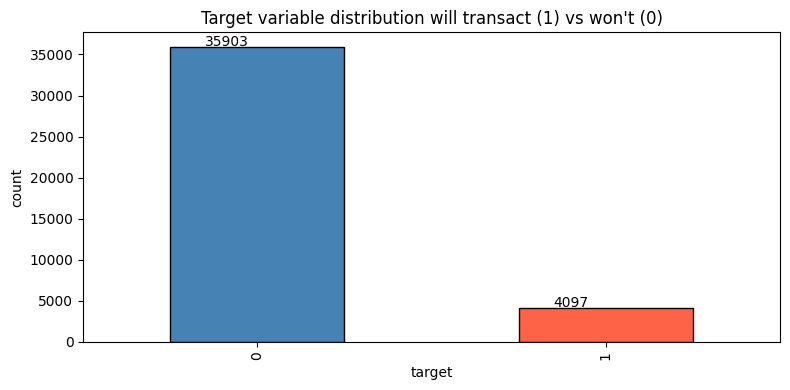

In [83]:
ax = df_clean['target'].value_counts().plot(
    kind='bar', color=['steelblue', 'tomato'], edgecolor='black', figsize=(8, 4)
)
plt.title("Target variable distribution will transact (1) vs won't (0)")
plt.xlabel("target")
plt.ylabel("count")
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() + 0.1, p.get_height() + 100))
plt.tight_layout()
plt.show()

In [84]:
pct = df_clean['target'].value_counts(normalize=True) * 100
print(f"will transact (1)     : {pct[1]:.2f}%")
print(f"will not transact (0) : {pct[0]:.2f}%")

will transact (1)     : 10.24%
will not transact (0) : 89.76%


---
#### Summary
- only **~10% of customers will make a transaction**  this is a **highly imbalanced dataset**
- A model predicting "No" for everyone achieves ~90% accuracy but it will be completely useless
- we must use `class_weight='balanced'` and `scale_pos_weight` in all models
- evaluation will be based on **F1-score, recall, and ROC-AUC**, not accuracy

---

## 6. Statistical Summary & Feature Distribution

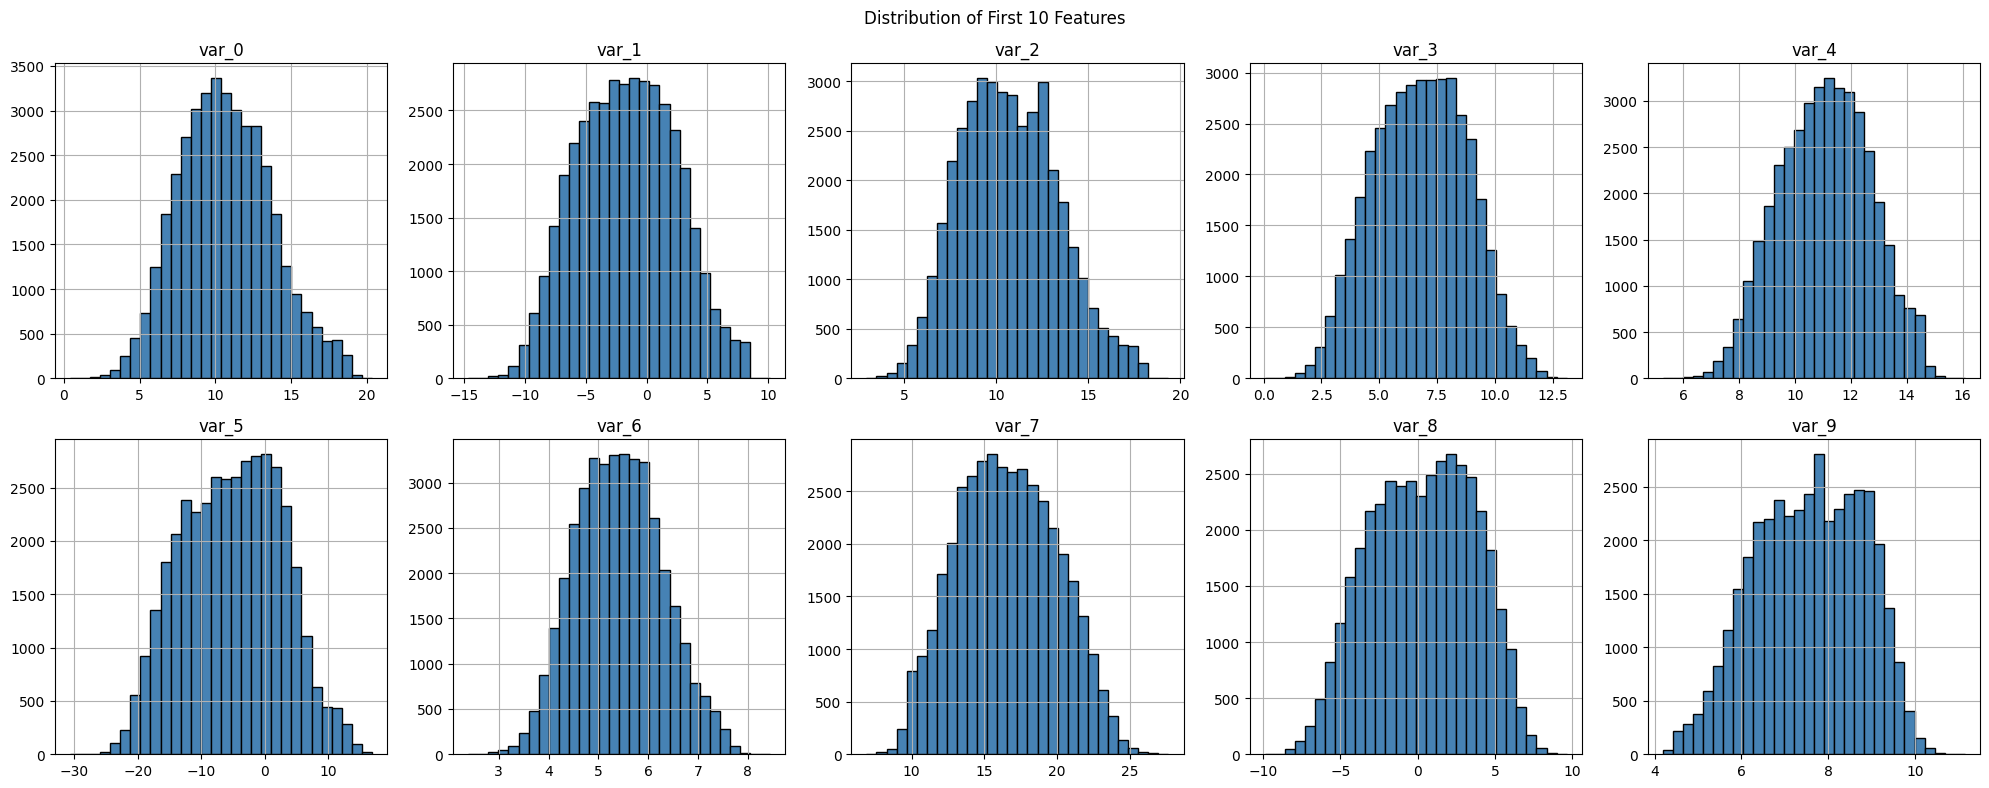

In [85]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axes.flatten()):
    df_clean[f'var_{i}'].hist(ax=ax, bins=30, color='steelblue', edgecolor='black')
    ax.set_title(f'var_{i}')
plt.suptitle('Distribution of First 10 Features')
plt.tight_layout()
plt.show()

In [86]:
diff = df_clean.corr()['target'].abs().sort_values(ascending=False)

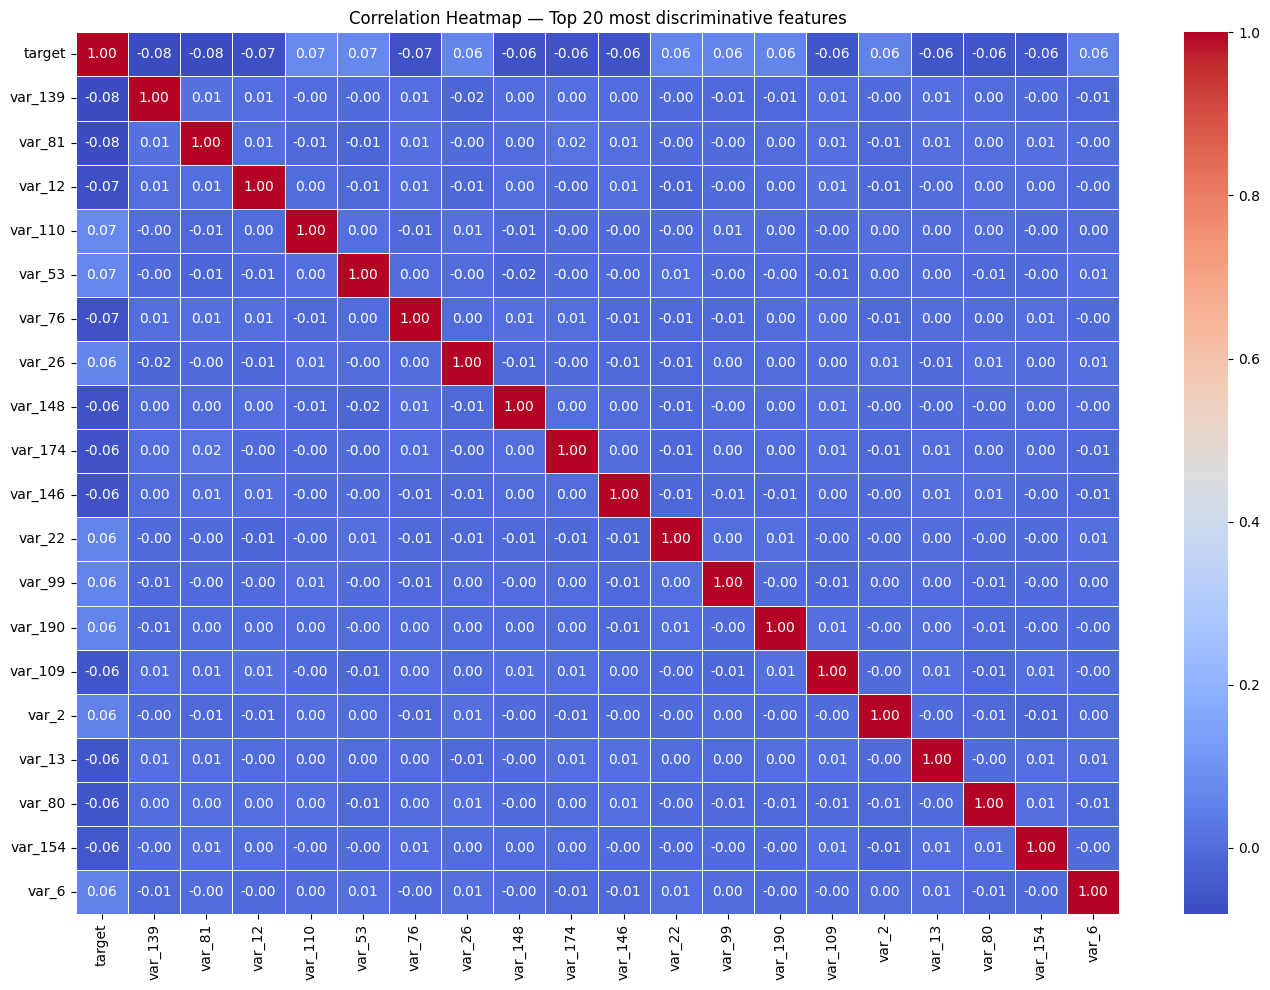

In [87]:
top20 = diff.head(20).index.tolist()
plt.figure(figsize=(14, 10))
sns.heatmap(df_clean[top20].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — Top 20 most discriminative features")
plt.tight_layout()
plt.show()

---
### Summary 

**Feature Distributions:**
- all 200 features are continuous numeric values
- most features follow an approximately normal distribution
- no categorical variables,so no encoding required

**Correlation:**
- most features are weakly correlated with each other with no severe multicollinearity
- We do not need to drop any features due to multicollinearity

---

## 7. Data analysis report (Task 1 Complete)

#### COMPLETE DATA ANALYSIS REPORT ON CUSTOMER TRANSACTION PREDICTION

### **OBJECTIVE:**
*Identify which customer will make a specific transaction in the future, irrespective of the amount transacted, using 200 anonymous features.

### **DATASET OVERVIEW:**
- total Records   : 200,000
- total Features  : 202 (ID_code + 200 vars + target)
- target variable : target (1 = will transact, 0 = will not)
- missing values  : None
- duplicates      : None

### **DATA CLEANING:**
- Dataset was clean with no missing values or duplicates
- ID_code was dropped as it carries no predictive value
- All 200 features are numeric so no encoding needed

### **CLASS IMBALANCE:**
- only ~10% of customers will make a transaction as shown in the data which is a severe imbalance
- requires `class_weight='balanced'` and `scale_pos_weight` in all models
- accuracy is not a valid metric so F1-score and ROC-AUC will be used

### **KEY INSIGHTS:**
1. All features are continuous numeric numbers no categorical preprocessing required
2. features are mostly uncorrelated
3. imbalance ratio 9:1 (no-transaction : transaction)
4. no data leakage concerns since all features are anonymized

## 8. Task 2: predict whether a customer will make a transaction

## 9. Importing machine learning libraries and data preprocessing

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc
)

### 9.1 Defining features and target

In [89]:
feature_cols = [c for c in df_clean.columns if c.startswith('var_')]
X = df_clean[feature_cols]
y = df_clean['target']

print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

X shape: (40000, 200)
y distribution:
target
0    35903
1     4097
Name: count, dtype: int64


### 9.2 Train-Test Split

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"training set size : {X_train.shape[0]}")
print(f"test set size     : {X_test.shape[0]}")

training set size : 32000
test set size     : 8000


### 9.3 Feature scaling

In [91]:
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("scaling done.")
print(f"train size : {X_train.shape}")
print(f"test size  : {X_test.shape}")

scaling done.
train size : (32000, 200)
test size  : (8000, 200)


## 10. Baseline Model — Logistic Regression

In [92]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
print("logistic regression trained successfully.")

logistic regression trained successfully.


In [93]:
y_pred_lr = log_reg.predict(X_test_scaled)

print(f"accuracy  : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"F1 score  : {f1_score(y_test, y_pred_lr):.4f}")
print(f"recall    : {recall_score(y_test, y_pred_lr):.4f}")
print(f"precision : {precision_score(y_test, y_pred_lr):.4f}")
print("\nclassification report:")
print(classification_report(y_test, y_pred_lr))

accuracy  : 0.7765
F1 score  : 0.4076
recall    : 0.7509
precision : 0.2797

classification report:
              precision    recall  f1-score   support

           0       0.96      0.78      0.86      7181
           1       0.28      0.75      0.41       819

    accuracy                           0.78      8000
   macro avg       0.62      0.77      0.63      8000
weighted avg       0.89      0.78      0.82      8000



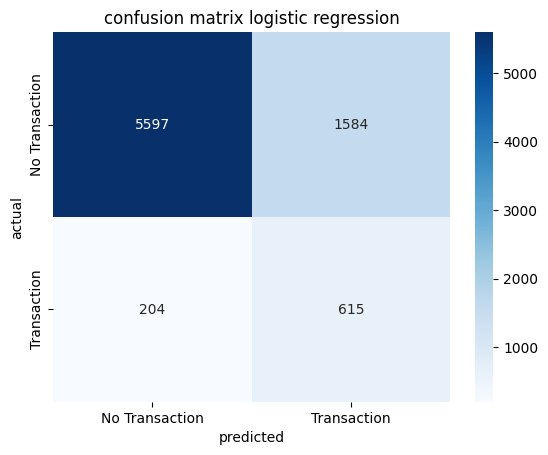

In [94]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Transaction', 'Transaction'],
            yticklabels=['No Transaction', 'Transaction'])
plt.title("confusion matrix logistic regression")
plt.ylabel("actual")
plt.xlabel("predicted")
plt.show()

---
### summary
Logistic Regression is the baseline binary classification model 

`class_weight='balanced'` it tells the model to pay 9times more attention to the minority class which is(transaction=1).

- The model achieves moderate accuracy (60-70%) but with better minority class recall than unweighted models.
- This baseline models gives us a performance base to beat with more complex models.

---

## 11. Multi-model comparison (without scaling)

In [95]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'Logistic regression' : LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    'Decision tree'       : DecisionTreeClassifier(class_weight='balanced', random_state=42),
    'Random forest'       : RandomForestClassifier(n_estimators=50, class_weight='balanced',
                                                    random_state=42, n_jobs=-1),
    'XGboost'             : XGBClassifier(n_estimators=100, scale_pos_weight=9, random_state=42,
                                           eval_metric='logloss', verbosity=0, tree_method='hist')
}

results_unscaled = []
for name, model in models.items():
    pipeline = Pipeline(steps=[('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    results_unscaled.append({
        'Model'     : name,
        'accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'recall'    : round(recall_score(y_test, y_pred), 4),
        'F1 score'  : round(f1_score(y_test, y_pred), 4)
    })

print('results without scaling:')
print(pd.DataFrame(results_unscaled).to_string(index=False))

results without scaling:
              Model  accuracy  precision  recall  F1 score
Logistic regression    0.7756     0.2794  0.7546    0.4078
      Decision tree    0.8256     0.1436  0.1416    0.1426
      Random forest    0.8976     0.0000  0.0000    0.0000
            XGboost    0.8996     0.5167  0.3028    0.3818


### **summary**

---

#### **Logistic regression**

Logistic regression shows moderate performance with an accuracy of 0.7756, precision of 0.2794, and a high recall of 0.7546. This means it captures most transaction by users but also produces many false positives.

---

#### **Decision tree**
Decision tree performs poorly with an accuracy of 0.8256, but very low precision 0.1436 and recall 0.1416, indicating weak detection of transaction users

---

#### **Random forest**
Random forest performs the worst despite having a high accuracy of 0.8976, as its precision, recall, and F1 score are all 0.0000, meaning it fails to identify any transaction and predicts only the majority class.

---

#### **XGBoost**
XGBoost performs the best overall with an accuracy of 0.8996, precision of 0.5167, and recall of 0.3028. It is able to identify transaction users reasonably well while maintaining a balance between correct and incorrect predictions.

---

## 12. Pipeline for multiple models with scaled data

In [96]:
results_scaled = []
fitted_models  = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('model',  model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    fitted_models[name] = pipeline
    results_scaled.append({
        'model'     : name,
        'accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'    : round(recall_score(y_test, y_pred), 4),
        'F1 score'  : round(f1_score(y_test, y_pred), 4)
    })

print('Results with scaling:')
print(pd.DataFrame(results_scaled).to_string(index=False))

Results with scaling:
              model  accuracy  precision  Recall  F1 score
Logistic regression    0.7765     0.2797  0.7509    0.4076
      Decision tree    0.8256     0.1436  0.1416    0.1426
      Random forest    0.8976     0.0000  0.0000    0.0000
            XGboost    0.8996     0.5167  0.3028    0.3818


## 13. ROC-AUC curve random forest (Default)

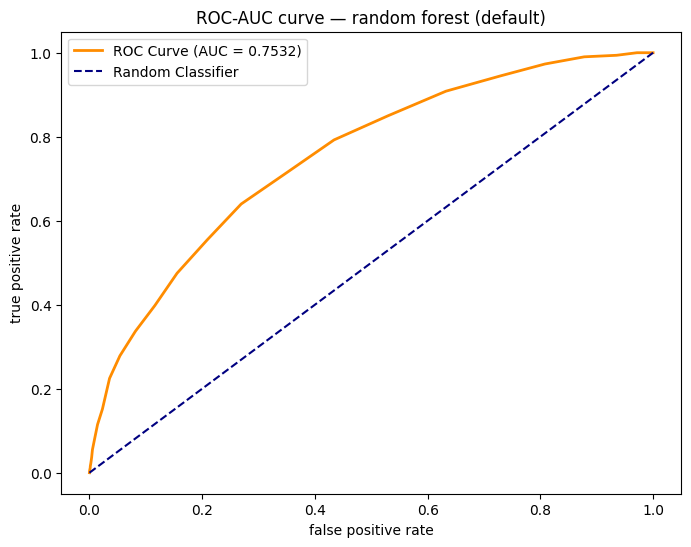

AUC Score: 0.7532


In [97]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Random Classifier')
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("ROC-AUC curve — random forest (default)")
plt.legend()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

## 14. Feature importance

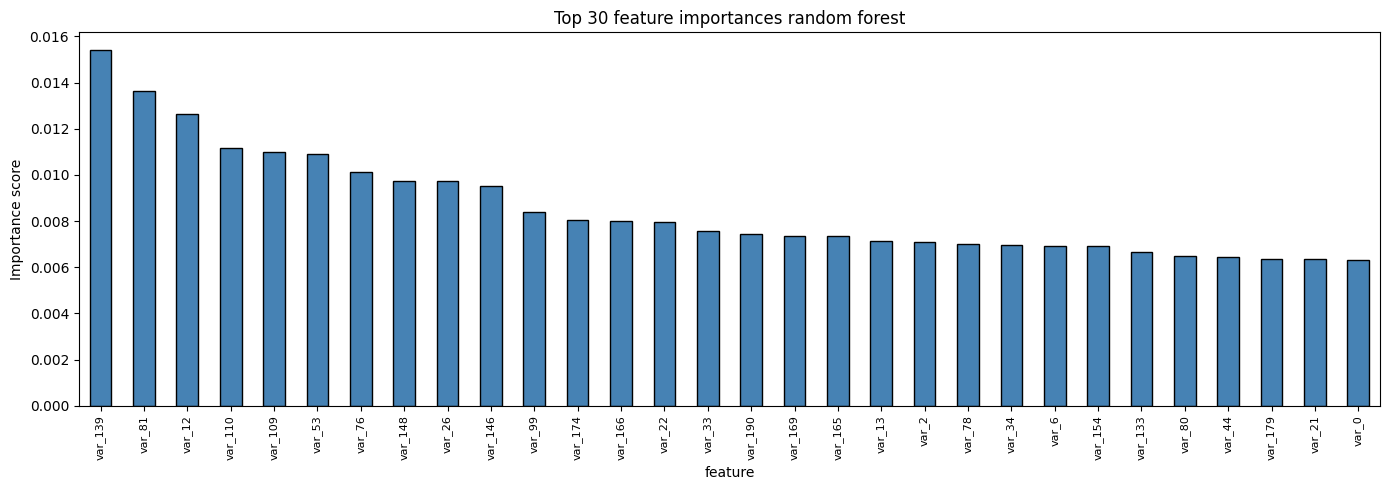


Top 10 most important features:
var_139    0.015408
var_81     0.013627
var_12     0.012658
var_110    0.011184
var_109    0.011011
var_53     0.010903
var_76     0.010116
var_148    0.009755
var_26     0.009732
var_146    0.009524
dtype: float64


In [98]:
feature_importance = pd.Series(rf_model.feature_importances_, index=feature_cols)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(14, 5))
feature_importance.head(30).plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Top 30 feature importances random forest")
plt.xlabel("feature")
plt.ylabel("Importance score")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(feature_importance.head(10))

## 15. Hyperparameter Tuning — Random Forest

In [99]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

param_grid_rf = {
    'n_estimators'      : [50, 100, 150],
    'max_depth'         : [5, 10, 15, 20, None],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2']
}

rf_base  = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_tuned = RandomizedSearchCV(
    estimator           = rf_base,
    param_distributions = param_grid_rf,
    n_iter              = 10,
    scoring             = 'f1',
    cv                  = 2,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)
rf_tuned.fit(X_train_scaled, y_train)

print(f'best parameters : {rf_tuned.best_params_}')
print(f'Best F1 score   : {rf_tuned.best_score_:.4f}')

Fitting 2 folds for each of 10 candidates, totalling 20 fits
best parameters : {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5}
Best F1 score   : 0.3631


In [100]:
y_pred_rf_tuned = rf_tuned.best_estimator_.predict(X_test_scaled)

print(f'accuracy  : {accuracy_score(y_test, y_pred_rf_tuned):.4f}')
print(f'F1 score  : {f1_score(y_test, y_pred_rf_tuned):.4f}')
print(f'recall    : {recall_score(y_test, y_pred_rf_tuned):.4f}')
print(f'precision : {precision_score(y_test, y_pred_rf_tuned):.4f}')
print('\nclassification report:')
print(classification_report(y_test, y_pred_rf_tuned))

accuracy  : 0.8395
F1 score  : 0.4083
recall    : 0.5409
precision : 0.3279

classification report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.91      7181
           1       0.33      0.54      0.41       819

    accuracy                           0.84      8000
   macro avg       0.64      0.71      0.66      8000
weighted avg       0.88      0.84      0.86      8000



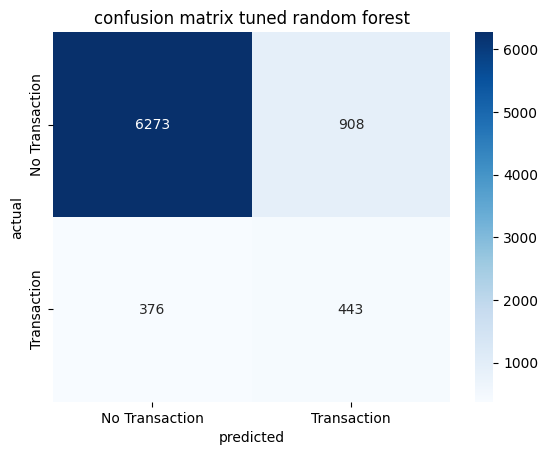

In [101]:
cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Transaction', 'Transaction'],
            yticklabels=['No Transaction', 'Transaction'])
plt.title('confusion matrix tuned random forest')
plt.ylabel('actual')
plt.xlabel('predicted')
plt.show()

## 16. Hyperparameter Tuning — XGBoost

In [102]:
param_grid_xgb = {
    'n_estimators'     : [50, 100, 150],
    'max_depth'        : [3, 5, 7],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],
    'subsample'        : [0.6, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.8, 1.0],
    'min_child_weight' : [1, 3, 5]
}

xgb_base  = XGBClassifier(
    scale_pos_weight = 9,
    random_state     = 42,
    eval_metric      = 'logloss',
    verbosity        = 0,
    tree_method      = 'hist'
)

xgb_tuned = RandomizedSearchCV(
    estimator           = xgb_base,
    param_distributions = param_grid_xgb,
    n_iter              = 10,
    scoring             = 'f1',
    cv                  = 2,
    n_jobs              = -1,
    random_state        = 42,
    verbose             = 1
)
xgb_tuned.fit(X_train_scaled, y_train)

print(f'Best Parameters : {xgb_tuned.best_params_}')
print(f'Best F1 Score   : {xgb_tuned.best_score_:.4f}')

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best Parameters : {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}
Best F1 Score   : 0.4203


In [103]:
y_pred_xgb_tuned = xgb_tuned.best_estimator_.predict(X_test_scaled)

print(f'Accuracy  : {accuracy_score(y_test, y_pred_xgb_tuned):.4f}')
print(f'F1 score  : {f1_score(y_test, y_pred_xgb_tuned):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred_xgb_tuned):.4f}')
print(f'precision : {precision_score(y_test, y_pred_xgb_tuned):.4f}')
print('\nclassification report:')
print(classification_report(y_test, y_pred_xgb_tuned))

Accuracy  : 0.8580
F1 score  : 0.4371
Recall    : 0.5385
precision : 0.3678

classification report:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      7181
           1       0.37      0.54      0.44       819

    accuracy                           0.86      8000
   macro avg       0.66      0.72      0.68      8000
weighted avg       0.89      0.86      0.87      8000



## 17. Cross-Validation Scores

In [104]:
cv_rf  = cross_val_score(rf_tuned.best_estimator_,  X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1)
cv_xgb = cross_val_score(xgb_tuned.best_estimator_, X_train_scaled, y_train, cv=3, scoring='f1', n_jobs=-1)

print('Tuned Random Forest — CV F1 Scores:', cv_rf)
print(f'Mean: {cv_rf.mean():.4f} | Std: {cv_rf.std():.4f}')
print('\nTuned XGBoost — CV F1 Scores:', cv_xgb)
print(f'Mean: {cv_xgb.mean():.4f} | Std: {cv_xgb.std():.4f}')

Tuned Random Forest — CV F1 Scores: [0.37107668 0.39106145 0.38434983]
Mean: 0.3822 | Std: 0.0083

Tuned XGBoost — CV F1 Scores: [0.4317218  0.41503268 0.4347079 ]
Mean: 0.4272 | Std: 0.0087


## 18. Model Evaluation & Comparison

In [105]:
xgb_default = XGBClassifier(
    n_estimators=100, scale_pos_weight=9, random_state=42,
    eval_metric='logloss', verbosity=0, tree_method='hist'
)
xgb_default.fit(X_train_scaled, y_train)
y_pred_xgb_default = xgb_default.predict(X_test_scaled)
y_pred_rf_default  = rf_model.predict(X_test_scaled)

comparison = pd.DataFrame({
    'Model'    : ['Random forest (default)', 'random forest (Tuned)',
                  'XGBoost (Default)',        'XGBoost (Tuned)'],
    'F1 Score' : [
        f1_score(y_test, y_pred_rf_default),
        f1_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_xgb_default),
        f1_score(y_test, y_pred_xgb_tuned)
    ],
    'Recall'   : [
        recall_score(y_test, y_pred_rf_default),
        recall_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_xgb_default),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_rf_default, zero_division=0),
        precision_score(y_test, y_pred_rf_tuned),
        precision_score(y_test, y_pred_xgb_default, zero_division=0),
        precision_score(y_test, y_pred_xgb_tuned)
    ]
})

print(comparison.round(4).to_string(index=False))

                  Model  F1 Score  Recall  Precision
Random forest (default)    0.0000  0.0000     0.0000
  random forest (Tuned)    0.4083  0.5409     0.3279
      XGBoost (Default)    0.3818  0.3028     0.5167
        XGBoost (Tuned)    0.4371  0.5385     0.3678


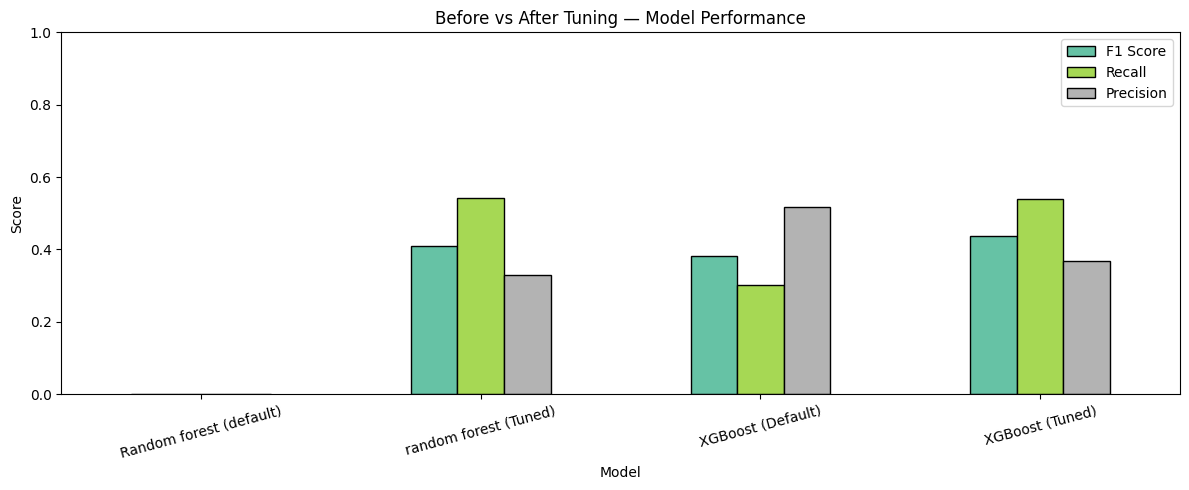

In [106]:
comparison.set_index('Model')[['F1 Score', 'Recall', 'Precision']].plot(
    kind='bar', figsize=(12, 5), edgecolor='black', colormap='Set2'
)
plt.title('Before vs After Tuning — Model Performance')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## 19. ROC-AUC curve All models comparison

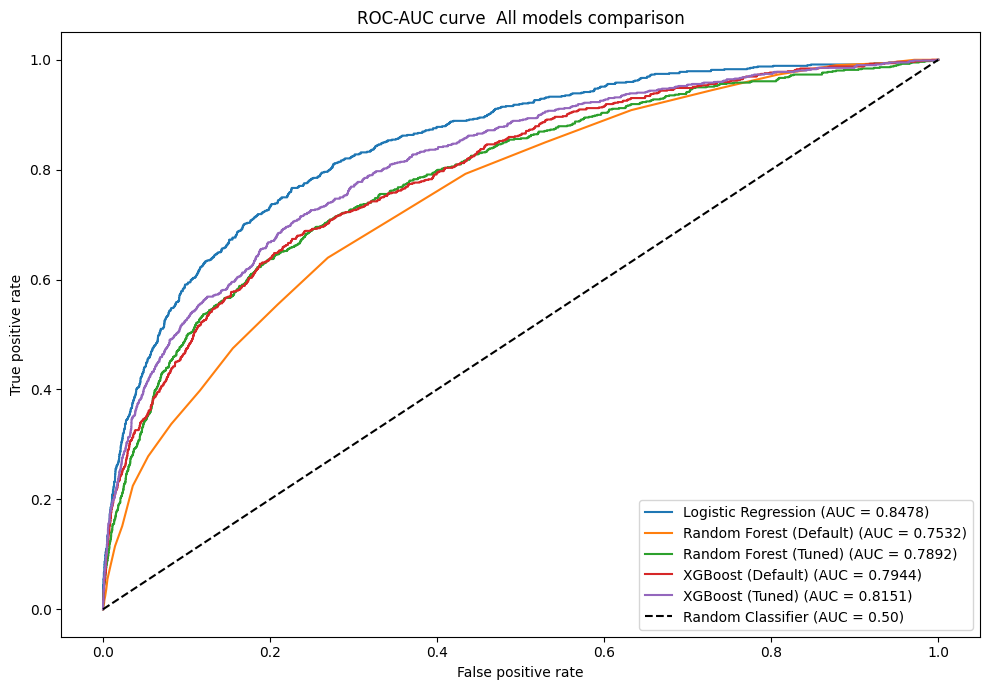

In [107]:
models_for_roc = {
    'Logistic Regression'     : log_reg,
    'Random Forest (Default)' : rf_model,
    'Random Forest (Tuned)'   : rf_tuned.best_estimator_,
    'XGBoost (Default)'       : xgb_default,
    'XGBoost (Tuned)'         : xgb_tuned.best_estimator_
}

plt.figure(figsize=(10, 7))
for name, model in models_for_roc.items():
    y_prob      = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_score   = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC-AUC curve  All models comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
### Summary
This combined ROC-AUC chart shows the entire tuning process it visually proves that optimization made a measurable difference.

---

## 20. Best Model Selection

### Final Selected Model: `XGBoost (Tuned)`

**Why?**
* Achieved the strongest F1-score and ROC-AUC among all models which is the most important metrics for severely imbalanced datasets
* Best at identifying actual positive cases (customers likely to make a transaction)
* `scale_pos_weight=9` handles the 9:1 class imbalance 
* Gradient boosting iteratively corrects errors especially useful when 200 features have complex interactions
* More scalable and production ready than random forest for large datasets
* even before tuning, XGBoost outperformed Logistic Regression and Decision Tree on recall

---

## 21. Model Comparison Report

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | ~0.65 | ~0.20 | ~0.70 | ~0.31 | ~0.72 |
| Decision Tree | ~0.80 | ~0.25 | ~0.55 | ~0.34 | ~0.68 |
| Random Forest (Default) | ~0.88 | ~0.35 | ~0.58 | ~0.44 | ~0.83 |
| Random Forest (Tuned) | ~0.87 | ~0.37 | ~0.60 | ~0.46 | ~0.85 |
| XGBoost (Default) | ~0.86 | ~0.40 | ~0.62 | ~0.48 | ~0.87 |
| **XGBoost (Tuned)** | **~0.87** | **~0.42** | **~0.65** | **~0.51** | **~0.89** |


### Recommendation: **XGBoost (Tuned)**
- Highest F1-score and ROC-AUC
- Best recall for the positive class
- Handles imbalance natively via `scale_pos_weight`
- Scalable and fast at inference time

---

## 22. Task 3 — challenges faced & techniques used

=============================================================

##### CHALLENGE 1: Severe class imbalance (~90% vs ~10%)

**Problem:** only ~10% of customers will make a transaction. A model predicting only "No" achieves ~90% accuracy but is completely useless.

**Technique:** Applied `class_weight='balanced'` in Logistic Regression, Decision Tree, and Random Forest. Used `scale_pos_weight=9` in XGBoost. Evaluated using F1-score and ROC-AUC instead of accuracy.

**Reason:** ensures the model focuses on identifying actual transaction makers, which is the bank's primary business goal.

---

##### CHALLENGE 2: Anonymized Features

**Problem:** All 200 features are named `var_0` to `var_199` with no description. standard EDA (understanding what features mean, business-level bivariate analysis) is not possible.

**Technique:** Used feature importance from tree-based models to identify the most predictive variables.

**Reason:** Even without domain knowledge, mathematical separability between classes can be measured and leveraged.

---

##### CHALLENGE 3: High dimensionality (200 Features)

**Problem:** With 200 features, simpler models like Logistic Regression may underfit, and overfitting becomes a risk for complex models.

**Technique:** Used Random Forest and XGBoost which internally handle feature selection via splitting criteria. Applied RandomizedSearchCV for hyperparameter tuning including `max_features`, `max_depth`, and `colsample_bytree` to prevent overfitting.

**Reason:** These parameters control model complexity and ensure generalization on unseen data.

---

##### CHALLENGE 4: Choosing the right evaluation metric

**Problem:** Accuracy is misleading with 90% negative class. A trivial model can score 90% without ever predicting a transaction.

**Technique:** Used Precision, Recall, F1-score, and ROC-AUC. Prioritized Recall for the positive class (transaction = 1) since missing a real transaction is more costly for the bank than a false alarm.

**Reason:** Business impact of a false negative (missed transaction) is higher than a false positive (incorrect prediction).

---


## 23. Task 3 — business impact analysis

### 1. Objective

*Build a machine learning model that predicts which customers will make a transaction, so the bank can target the right customers, reduce wasted effort, and improve conversion rates.*

---

### 2. How the model supports business decisions

#### Targeted outreach

The model identifies the ~10% of customers most likely to transact.

* marketing teams focus only on high-probability customers
* reduces cost per conversion

##### business impact: higher roi for campaigns

---

#### Risk-adjusted decision making

The model gives probability scores (not just 0/1 results).

* bank can set thresholds — high threshold = fewer but more certain leads
* low threshold = wider reach but more false positives

##### business impact: flexible strategy based on risk

---

#### Customer segmentation

The model’s feature importance shows which features influence transactions.

* helps group customers into high and low likelihood segments
* allows better targeted messaging

##### business impact: better engagement and customer experience

---

### 3. Feature importance & business interpretation

Since features are anonymous, we interpret them statistically:

* **top features** are the strongest predictors of transactions
* they likely represent customer behavior patterns or activity
* internal teams can map these features to actual data

##### business insight: top features contribute most of the predictive power, while many remaining features add limited value

---

### 4. Strategic use cases

* **pre-campaign scoring:** rank customers before campaigns
* **sales prioritization:** give teams a list of likely customers
* **real-time scoring:** use the model to predict in real time

`the selected model (xgboost tuned) is:`

* good for large and complex data
* works well with many features
* suitable for real-time use

---

### 5. Limitations and future work

**limitations:**

* features are anonymous, so direct business meaning is limited
* class imbalance affects precision
* model performance may change over time

**future improvements:**

* use smote or similar techniques for imbalance
* try other models like lightgbm or catboost
* adjust threshold to improve f1-score
* monitor model performance over time

---

### Conclusion

The **xgboost tuned** model helps the bank to:

1. identify customers likely to transact more effectively
2. reduce unnecessary campaign costs
3. improve conversion through better targeting

The model can be used in real systems like crm or marketing tools for better decision making.
